In [ ]:
%pip install yfinance
%pip install matplotlib

   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ------------------------- -------------- 1.0/1.7 MB 5.0 MB/s eta 0:00:01
   ---------------------------------------- 1.7/1.7 MB 4.7 MB/s  0:00:00

   ----------------------------------------  0/17 [pytz]
   ----------------------------------------  0/17 [pytz]
   -- -------------------------------------  1/17 [peewee]
   -- -------------------------------------  1/17 [peewee]
   -- -------------------------------------  1/17 [peewee]
   ------- --------------------------------  3/17 [websockets]
   ------- --------------------------------  3/17 [websockets]
   --------- ------------------------------  4/17 [urllib3]
   --------- ------------------------------  4/17 [urllib3]
   ---------------- -----------------------  7/17 [protobuf]
   ---------------- -----------------------  7/17 [protobuf]
   ---------------- -----------------------  7/17 [protobuf]
   ------------------ ---------------------  8/17 [idna]
   -

In [ ]:
%pip install pandas nltk textblob requests


  Using cached nltk-3.9.4-py3-none-any.whl.metadata (3.2 kB)
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ------------- -------------------------- 0.5/1.6 MB 4.2 MB/s eta 0:00:01
   ---------------------------------------- 1.6/1.6 MB 4.6 MB/s  0:00:00
   ---------------------------------------- 0.0/625.0 kB ? eta -:--:--
   ---------------------------------------- 625.0/625.0 kB 3.9 MB/s  0:00:00

   ---------------------------------------- 0/6 [tqdm]
   ------ --------------------------------- 1/6 [regex]
   ------------- -------------------------- 2/6 [joblib]
   ------------- -------------------------- 2/6 [joblib]
   ------------- -------------------------- 2/6 [joblib]
   ------------- -------------------------- 2/6 [joblib]
   -------------------- ------------------- 3/6 [click]
   -------------------------- ------------- 4/6 [nltk]
   -------------------------- ------------- 4/6 [nltk]
   -------------------------- ------------- 4/6 [nltk]
   ---------

In [6]:
import yfinance as yf
import pandas as pd
stock = yf.download("AAPL", period ="6mo")

print(stock.head())

[*********************100%***********************]  1 of 1 completed

Price            Close        High         Low        Open    Volume
Ticker            AAPL        AAPL        AAPL        AAPL      AAPL
Date                                                                
2025-12-23  271.854919  271.994674  269.060124  270.337749  29642000
2025-12-24  273.302216  274.919206  271.695216  271.834940  17910600
2025-12-26  272.893005  274.859353  272.353998  273.651606  21521800
2025-12-29  273.252350  273.851213  271.844961  272.184327  23715200
2025-12-30  272.573547  273.571693  271.775043  272.304059  22139600


In [8]:
import requests

api_key = "a8dbbf5abebe4a289c1aaf7e1967269c"

url = f"https://newsapi.org/v2/everything?q=Apple&apiKey={api_key}"

data = requests.get(url).json()

articles = data["articles"]

for article in articles[:5]:
    print(article["title"])

Cameras get an Apple Intelligence boost in Apple Home
Apple announces iOS 27
Apple announces iPadOS 27
Apple wants Europe to blink
Apple is using AI to fix Safari’s extension problem


In [13]:
import nltk
nltk.download('vader_lexicon')
from nltk.sentiment import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()

headline = "Apple reports record quarterly profits"

score = sia.polarity_scores(headline)

print(score)

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\barat\AppData\Roaming\nltk_data...


{'neg': 0.0, 'neu': 0.58, 'pos': 0.42, 'compound': 0.4404}


In [14]:
sentiments = []

for article in articles:
    title = article["title"]

    score = sia.polarity_scores(title)["compound"]

    sentiments.append(score)

average_sentiment = sum(sentiments)/len(sentiments)

print("Average Sentiment:", average_sentiment)

Average Sentiment: 0.10816025641025642


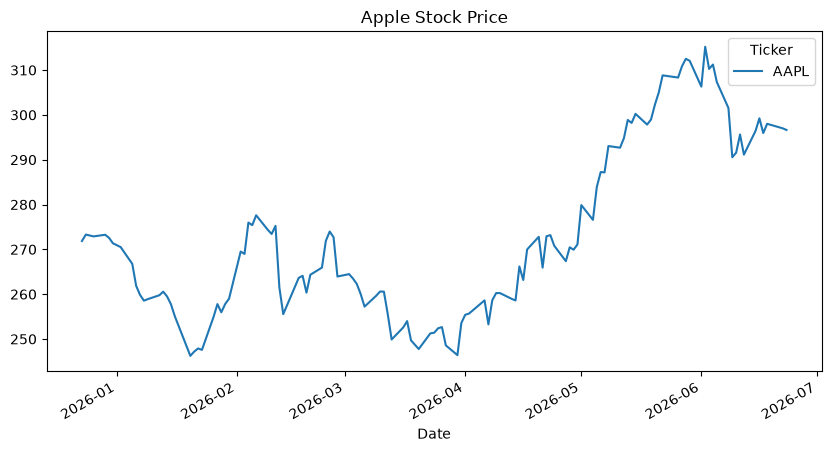

In [15]:
import matplotlib.pyplot as plt

stock["Close"].plot(figsize=(10,5))

plt.title("Apple Stock Price")
plt.show()